<a href="https://colab.research.google.com/github/Heng1222/Ohsumed_classification/blob/feat-token-size/Model/Token_size_distribution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Tokenizer 表現觀察 MeSH & nltk Random

In [132]:
import nltk
from nltk.corpus import brown
from collections import Counter
import pandas as pd
import random

# 1. 下載語料庫 (僅在第一次執行時下載)
nltk.download('brown')
nltk.download('universal_tagset')

def get_random_nouns_df(num_words: int) -> list:
    """
    Generates a list of randomly sampled common English nouns based on frequency.
    Args:
        num_words (int): The number of random nouns to sample.
    Returns:
        list: A list containing the sampled and sorted nouns.
    """
    # 2. 獲取布朗語料庫中的所有名詞，並統計頻率
    # 使用 universal_tagset 確保精準標記為 'NOUN'
    words_with_tag = brown.tagged_words(tagset='universal')

    # 過濾：長度 4-12 字、純字母、非全大寫縮寫
    nouns = [
        word.lower() for word, tag in words_with_tag
        if tag == 'NOUN'
        and word.isalpha()
        and 4 <= len(word) <= 12
        and not word.isupper()
    ]

    # 3. 取得高頻名詞池 (取前 5000 個高頻詞作為隨機挑選的母體)
    # 這樣可以避開一些奇怪、極少見的單字組合
    common_nouns_counts = Counter(nouns).most_common(10000)
    common_noun_pool = [word for word, count in common_nouns_counts]

    # 4. 執行隨機挑選
    if len(common_noun_pool) >= num_words:
        random_nouns = random.sample(common_noun_pool, num_words)
    else:
        random_nouns = common_noun_pool
        print(f"警告：符合條件的高頻名詞僅有 {len(common_noun_pool)} 個，將選取全部名詞。")

    # 5. 排序並輸出 list
    random_nouns.sort()
    df_output = pd.DataFrame(random_nouns, columns=['Random_Noun'])

    print(f"✅ 已從高品質日常語料中隨機挑選 {len(random_nouns)} 個名詞！")
    return df_output['Random_Noun'].tolist()

# --- 使用範例 ---
# my_word_list = get_random_nouns_df(3000)
# print(my_word_list[:10])

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!


In [133]:
# 1. 測試資料集 (Python List of Strings)
import pandas as pd
url = 'https://github.com/Heng1222/Ohsumed_classification/blob/main/MeSH_data/mesh_dataset.csv?raw=true'
full_df = pd.read_csv(url)
# 範例： ["Myocardial Infarction", "Diabetes Mellitus", "Acetylcholinesterase", ...]
mesh_terms_set = set(pd.concat([full_df["word_i"], full_df["word_j"]]))
random_words = get_random_nouns_df(num_words=5080)



# 2. 模型字典 (Dictionary of Tokenizers)
# Key 為模型名稱 (自訂)，Value 為已經 load 好的 Hugging Face Tokenizer 物件
# 範例：
# tokenizers_dict = {
#     "Llama-3": AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3-8B"),
#     "BioMistral": AutoTokenizer.from_pretrained("BioMistral/BioMistral-7B"),
#     "Gemma-2": AutoTokenizer.from_pretrained("google/gemma-2-9b")
# }
from transformers import RobertaTokenizer
tokenizers_dict = {
  "RoBERTa": RobertaTokenizer.from_pretrained('roberta-base')
}

✅ 已從高品質日常語料中隨機挑選 5080 個名詞！


正在分析 5080 個 MeSH 詞彙...
Processing RoBERTa...


100%|██████████| 5080/5080 [00:00<00:00, 10295.06it/s]


正在分析 5080 個 MeSH 詞彙...
Processing RoBERTa...


100%|██████████| 5080/5080 [00:00<00:00, 13937.61it/s]


      Model                         Term  Char_Length  Word_Count  \
0   RoBERTa                stomach ulcer           13           2   
1   RoBERTa               mptp poisoning           14           2   
2   RoBERTa                 lyme disease           12           2   
3   RoBERTa                  reinfection           11           1   
4   RoBERTa                  sarcoidosis           11           1   
5   RoBERTa       pachyonychia congenita           22           2   
6   RoBERTa           parasitic diseases           18           2   
7   RoBERTa         heart valve prolapse           20           3   
8   RoBERTa  meibomian gland dysfunction           27           3   
9   RoBERTa                        warts            5           1   
10  RoBERTa         urticaria pigmentosa           20           2   
11  RoBERTa          myocardial ischemia           19           2   
12  RoBERTa               laron syndrome           14           2   
13  RoBERTa        postpartum hemo

Char_Length                                                    \
                   count       mean       std  min   25%   50%   75%   max   
Dataset_Type                                                                 
MeSH Terms        5080.0  19.924213  8.199254  4.0  14.0  19.0  24.0  63.0   
Random Words      5080.0   7.202559  2.140036  4.0   5.0   7.0   9.0  12.0   

             Word_Count            ... Tokens_per_Word        \
                  count      mean  ...             75%   max   
Dataset_Type                       ...                         
MeSH Terms       5080.0  2.166929  ...             3.0  12.0   
Random Words     5080.0  1.000000  ...             2.0   6.0   

             Fragmentation_Rate                                               \
                          count      mean       std  min  25%  50%       75%   
Dataset_Type                                                                   
MeSH Terms               5080.0  0.087853  0.122236  0.0  0.0  0.0  0.166667   
Random Words             5080.0  0.103566  0.188031  0.0  0.0  0.0  0.000000   

                        
                   max  
Dataset_Type            
MeSH Terms    0.666667  
Random Words  0.666667  

[2 rows x 48 columns]

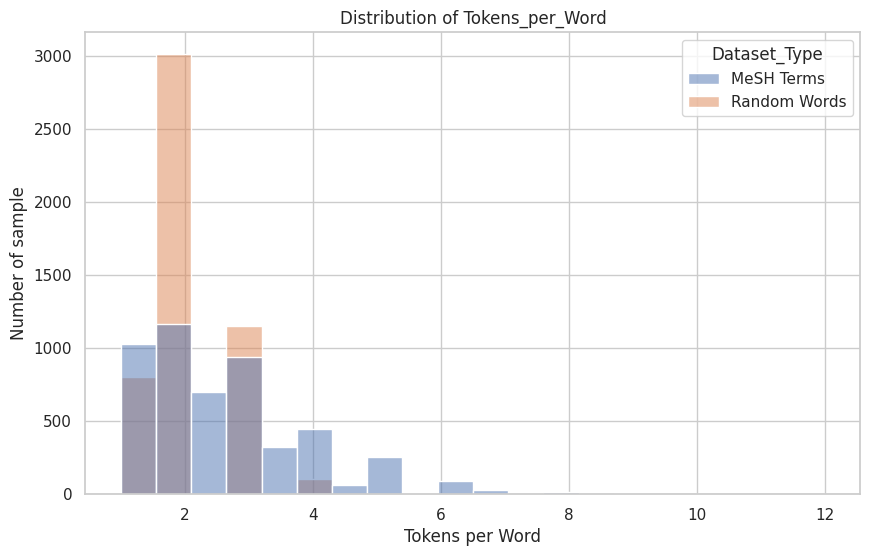

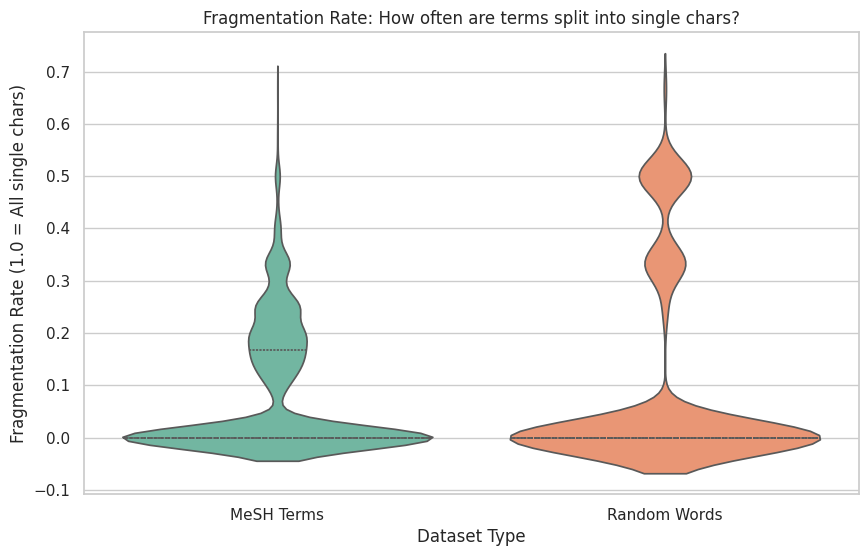

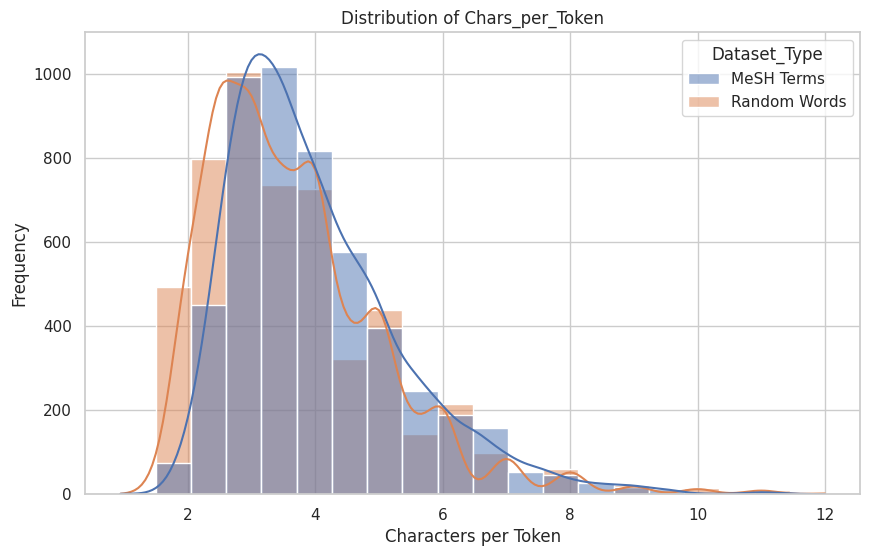

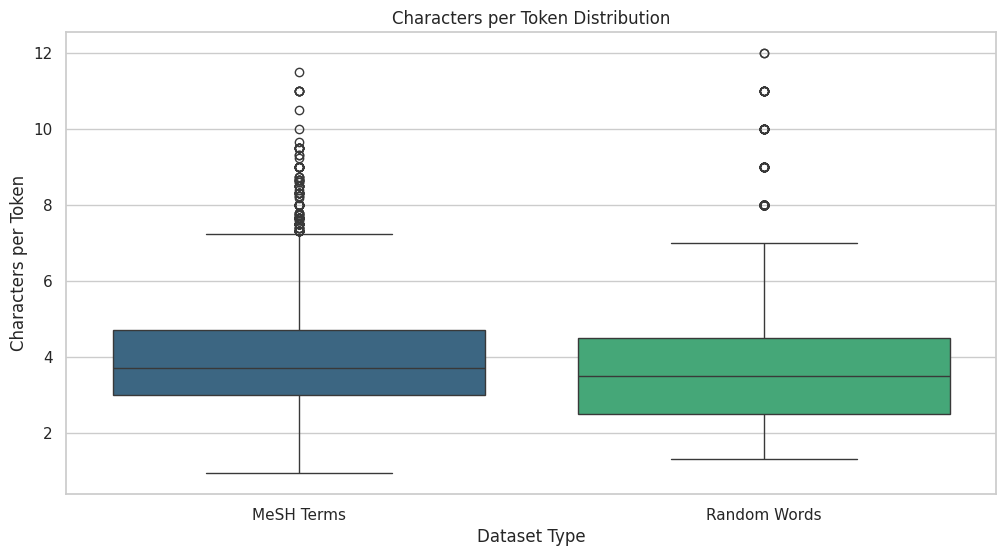

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# --- 設定繪圖風格 ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

def calculate_token_metrics(text, tokenizer, model_name):
    """
    計算單個詞彙在特定 Tokenizer 下的各項指標
    """
    # 重要：add_special_tokens=False 以避免 [BOS]/[CLS] 影響統計
    tokens = tokenizer.tokenize(text, add_special_tokens=False)
    ids = tokenizer.encode(text, add_special_tokens=False)

    token_count = len(tokens)
    char_count = len(text)

    # 新增：計算單字數量 (以空格切割)
    words = text.split()
    word_count = len(words)

    # 避免除以零
    if token_count == 0: return None

    if word_count == 0:
        tokens_per_word = 0.0 # If text is empty or only spaces
    else:
        tokens_per_word = token_count / word_count

    # 1. 字元/Token 比 (Compression Rate): 越高越好，代表一個 Token 能攜帶更多資訊
    chars_per_token = char_count / token_count

    # 2. 碎片化程度 (Fragmentation Score):
    # 計算長度只有 1 的 token (通常是單字母或 byte fallback) 佔總 token 的比例
    # 比例越高代表模型對此詞彙越陌生，被迫拆成字母
    single_char_tokens = sum(1 for t in tokens if len(t.replace('Ġ', '').replace(' ', '')) == 1)
    fragmentation_rate = single_char_tokens / token_count

    return {
        "Model": model_name,
        "Term": text,
        "Char_Length": char_count,
        "Word_Count": word_count,  # 新增：單字數量
        "Token_Count": token_count,
        "Chars_per_Token": chars_per_token,      # 越高越好 (編碼效率高)
        "Tokens_per_Word": tokens_per_word,      # 新增：每個單字平均被切成多少 Token
        "Fragmentation_Rate": fragmentation_rate # 越低越好 (0 代表沒有單字母拆解)
    }

def run_mesh_analysis(terms_list, tokenizers_map):
    results = []

    print(f"正在分析 {len(terms_list)} 個 MeSH 詞彙...")

    for model_name, tokenizer in tokenizers_map.items():
        print(f"Processing {model_name}...")
        for term in tqdm(terms_list):
            metrics = calculate_token_metrics(term, tokenizer, model_name)
            if metrics:
                results.append(metrics)

    return pd.DataFrame(results)

# --- 執行分析 ---
# df_results 是你主要的分析表格
df_1 = run_mesh_analysis(mesh_terms_set, tokenizers_dict)
df_1['Dataset_Type'] = 'MeSH Terms'
df_2 = run_mesh_analysis(random_words, tokenizers_dict)
df_2['Dataset_Type'] = 'Random Words'
df_results = pd.concat([df_1, df_2], ignore_index=True)
print(df_results.head(20))
# --- 查看數據摘要 ---
# 顯示 RoBERTa 模型的詳細描述性統計
roberta_df = df_results[df_results['Model'] == 'RoBERTa']
print("\n=== RoBERTa Tokenizer 詳細統計數據 ===")
display(roberta_df.groupby('Dataset_Type')[["Char_Length", "Word_Count", "Token_Count", "Chars_per_Token", "Tokens_per_Word", "Fragmentation_Rate"]].describe())

# 圖表 1: Tokens_per_Word 分布 (Boxplot)
# 觀察：
plt.figure(figsize=(10, 6))
sns.histplot(data=df_results, x="Tokens_per_Word", bins=20, hue="Dataset_Type", color='skyblue')
plt.title("Distribution of Tokens_per_Word")
plt.ylabel("Number of sample")
plt.xlabel("Tokens per Word")
plt.show()

# 圖表 2: 碎片化程度 (Violin Plot or Strip Plot)
# 觀察：是否有模型經常出現高碎片化 (Fragmentation > 0.5)
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_results, x="Dataset_Type", y="Fragmentation_Rate", hue="Dataset_Type", palette="Set2", inner="quartile", legend=False)
plt.title("Fragmentation Rate: How often are terms split into single chars?")
plt.ylabel("Fragmentation Rate (1.0 = All single chars)")
plt.xlabel("Dataset Type")
plt.show()

# 圖表 3: Chars_per_Token 整體分佈
# 觀察：每個 Token 平均承載的字元數的分佈狀況
plt.figure(figsize=(10, 6))
sns.histplot(data=df_results, x="Chars_per_Token", kde=True, bins=20, hue="Dataset_Type", color='skyblue')
plt.title("Distribution of Chars_per_Token")
plt.xlabel("Characters per Token")
plt.ylabel("Frequency")
plt.show()
# 圖表 4: Characters per Token 整體分佈
# 觀察：
sns.boxplot(data=df_results, x="Dataset_Type", y="Chars_per_Token", hue="Dataset_Type", palette="viridis", legend=False)
plt.title("Characters per Token Distribution")
plt.ylabel("Characters per Token")
plt.xlabel("Dataset Type")
plt.show()

### RoBERTa Tokenizer 表現極端範例

In [135]:
# 顯示 Token 數量最多的前 5 個 MeSH 詞彙
display_df = df_results[df_results['Dataset_Type'] == 'MeSH Terms']

print("\n=== Token 數量最多的 MeSH 詞彙 (RoBERTa) ===")
display(display_df.sort_values(by='Chars_per_Token', ascending=True).head(30))


=== Token 數量最多的 MeSH 詞彙 (RoBERTa) ===


,Model,Term,Char_Length,Word_Count,Token_Count,Chars_per_Token,Tokens_per_Word,Fragmentation_Rate,Dataset_Type
313,RoBERTa,нервной системы центральной болезни,35,4,37,0.945946,9.25,0.243243,MeSH Terms
3148,RoBERTa,covid-19,8,1,5,1.600000,5.00,0.400000,MeSH Terms
3127,RoBERTa,pinta,5,1,3,1.666667,3.00,0.666667,MeSH Terms
2250,RoBERTa,nevus,5,1,3,1.666667,3.00,0.333333,MeSH Terms
2961,RoBERTa,bruxism,7,1,4,1.750000,4.00,0.500000,MeSH Terms
4503,RoBERTa,sarcoma,7,1,4,1.750000,4.00,0.500000,MeSH Terms
4711,RoBERTa,dyspnea,7,1,4,1.750000,4.00,0.500000,MeSH Terms
499,RoBERTa,dysgeusia,9,1,5,1.800000,5.00,0.200000,MeSH Terms
2962,RoBERTa,dyspepsia,9,1,5,1.800000,5.00,0.200000,MeSH Terms
1958,RoBERTa,pemphigus,9,1,5,1.800000,5.00,0.200000,MeSH Terms


In [136]:
# 顯示碎片化率最高的前 5 個 MeSH 詞彙 (表示這些詞彙被拆解成單字元的比例最高)
print("\n=== 碎片化率最高的 MeSH 詞彙 (RoBERTa) ===")
display(display_df.sort_values(by='Fragmentation_Rate', ascending=False).head(5))


=== 碎片化率最高的 MeSH 詞彙 (RoBERTa) ===


,Model,Term,Char_Length,Word_Count,Token_Count,Chars_per_Token,Tokens_per_Word,Fragmentation_Rate,Dataset_Type
4541,RoBERTa,nausea,6,1,3,2.000000,3.00,0.666667,MeSH Terms
3127,RoBERTa,pinta,5,1,3,1.666667,3.00,0.666667,MeSH Terms
207,RoBERTa,vitamin b 6 deficiency,22,4,5,4.400000,1.25,0.600000,MeSH Terms
3924,RoBERTa,fetus-in-fetu,13,1,7,1.857143,7.00,0.571429,MeSH Terms
4967,RoBERTa,nail-patella syndrome,21,2,7,3.000000,3.50,0.571429,MeSH Terms
